## Ejercicio 1

Implemente las estructuras de datos y algoritmos básicos para la solución de un problema mediante algoritmos genéticos. Pruebe estas rutinas y compare los resultados con un método de gradiente descendiente para buscar el mínimo global de las siguientes funciones:

### Idea del algoritmo evolutivo

Cada individuo es una solución posible, guardada como una lista de bits. En cada generación los mejores individuos tienen más chance de ser padres. Los hijos mezclan los bits de dos padres y a veces cambian algún bit. Así la población mejora generación tras generación.

```mermaid
flowchart TD
    A["Población inicial:<br/>individuos con<br/>bits al azar"] --> B["1. Evaluar: decodificar<br/>cada individuo a (x) o (x, y)<br/>y calcular aptitud = −f"]
    B --> C{"¿Se alcanzó el máximo<br/>de generaciones?"}
    C -- Sí --> Z(["Fin: mejor individuo"])
    C -- No --> E["2. Elitismo: el mejor<br/>pasa directo a la<br/>nueva población"]
    E --> D["3. Selección por torneo:<br/>padre y madre"]
    D --> F["3. Cruce en un punto<br/>→ 2 hijos"]
    F --> G["3. Mutación: cada bit<br/>cambia con prob. 1/n_bits"]
    G --> I{"¿Nueva población<br/>completa?"}
    I -- No --> D
    I -- Sí --> B
```

- La función `algoritmo_genetico` hace la selección, el cruce, la mutación y el elitismo. No sabe qué problema resuelve: recibe la población inicial y dos funciones del problema, `decodificar` (qué representa un individuo) y `aptitud` (qué tan bueno es). El ejercicio 2 usa la misma función, con otra población y otras dos funciones.
- Para evaluar un individuo, primero se **decodifica**: cada grupo de bits se pasa a un número real.
- El algoritmo busca la **mayor** aptitud. Nosotros buscamos el **mínimo** de $f$. Por eso la aptitud es $-f$.

| | Inciso 1 | Inciso 2 |
|---|---|---|
| Individuo | 20 bits → $x \in [-512, 512]$ | 20 + 20 bits → $(x, y) \in [-100, 100]^2$ |
| Resolución | $1024 / (2^{20}-1) \approx 0.001$ | $200 / (2^{20}-1) \approx 0.0002$ |
| Mínimo global | $f(420.97) \approx -418.98$ | $f(0, 0) = 0$ |

### Implementación del algoritmo genético

El algoritmo está separado en funciones chicas. Cada función hace una sola parte del diagrama. Al final, `algoritmo_genetico` las junta.

In [1]:
import math
import random
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Crear un individuo

Un individuo es una lista de bits (ceros y unos). Esta función crea un individuo con bits al azar.

In [2]:
#un individuo es una lista de bits al azar, por ejemplo [1, 0, 0, 1, ...]
def crear_bits_al_azar(n_bits):
    individuo = []
    for i in range(n_bits):
        individuo.append(random.randint(0, 1))
    return individuo

#### Selección por torneo

Esta función elige un padre. Toma 3 individuos al azar y devuelve el de mayor aptitud. Los individuos buenos ganan más seguido, pero los malos también tienen alguna chance.

In [3]:
#torneo de 3: elijo 3 individuos al azar y gana el de mayor aptitud
def seleccion(poblacion, aptitudes):
    ganador = random.randrange(len(poblacion))
    for i in range(2):
        rival = random.randrange(len(poblacion))
        if aptitudes[rival] > aptitudes[ganador]:
            ganador = rival
    return poblacion[ganador]

#### Cruce en un punto

Esta función mezcla dos padres. Elige un punto de corte al azar y arma dos hijos: cada hijo tiene el principio de un padre y el final del otro.

Ejemplo con el corte después de la posición 2:

```
padre = [1, 1 | 0, 0, 0]        hijo1 = [1, 1, 1, 0, 1]
madre = [0, 1 | 1, 0, 1]        hijo2 = [0, 1, 0, 0, 0]
```

El 10 % de las veces no hay cruce: los hijos son copias de los padres.

In [4]:
#cruce en un punto: corto a los dos padres en el mismo lugar e intercambio las partes
#el 10% de las veces no se cruzan y los hijos son copias de los padres
def cruce(padre, madre):
    if random.random() < 0.9:
        corte = random.randint(1, len(padre) - 1)
        hijo1 = padre[:corte] + madre[corte:]
        hijo2 = madre[:corte] + padre[corte:]
    else:
        hijo1 = padre[:]
        hijo2 = madre[:]
    return hijo1, hijo2

#### Mutación

Esta función recorre los bits de un hijo. Cada bit cambia (0 → 1 o 1 → 0) con probabilidad $1/n_{bits}$, así que en promedio cambia un bit por hijo. La mutación agrega variedad: puede crear bits que ningún padre tenía.

In [5]:
#cada bit cambia (0 -> 1 o 1 -> 0) con probabilidad 1/n_bits: en promedio cambia 1 bit por hijo
def mutacion(individuo):
    mutado = []
    for bit in individuo:
        if random.random() < 1 / len(individuo):
            mutado.append(1 - bit)
        else:
            mutado.append(bit)
    return mutado

#### El mejor de la población

Esta función devuelve la posición del individuo con mayor aptitud.

In [6]:
#posicion del individuo con mayor aptitud
def indice_del_mejor(aptitudes):
    mejor = 0
    for i in range(len(aptitudes)):
        if aptitudes[i] > aptitudes[mejor]:
            mejor = i
    return mejor

#### El algoritmo completo

Esta función junta las anteriores en el orden del diagrama. En cada generación:

- **Paso 1:** evalúa la aptitud de todos los individuos.
- **Paso 2 (elitismo):** copia el mejor individuo a la nueva población.
- **Paso 3:** completa la nueva población con hijos: selección, cruce y mutación.

La función recibe la población inicial y dos funciones del problema:

- `decodificar(individuo)`: pasa los bits a lo que representan (un punto o una lista de genes).
- `aptitud(individuo)`: dice qué tan bueno es el individuo. Mayor es mejor.

También guarda datos de cada generación para los gráficos: la población decodificada, el mejor individuo y su aptitud.

In [7]:
#algoritmo genetico: no sabe que problema resuelve, por eso recibe la poblacion inicial
#y dos funciones del problema:
#  decodificar(individuo): lo pasa a lo que representa (un punto, una lista de genes, ...)
#  aptitud(individuo):     que tan bueno es (mayor = mejor)
def algoritmo_genetico(poblacion, decodificar, aptitud, max_generaciones=200):

    #guardo informacion de cada generacion para graficar despues
    poblaciones = []            #todos los individuos decodificados
    mejores = []                #el mejor individuo decodificado
    aptitudes_mejores = []      #la aptitud del mejor

    for generacion in range(max_generaciones):
        #1. evaluo a toda la poblacion
        aptitudes = []
        decodificados = []
        for individuo in poblacion:
            aptitudes.append(aptitud(individuo))
            decodificados.append(decodificar(individuo))

        mejor = indice_del_mejor(aptitudes)
        poblaciones.append(decodificados)
        mejores.append(decodificados[mejor])
        aptitudes_mejores.append(aptitudes[mejor])

        #2. elitismo: el mejor pasa directo a la nueva poblacion
        nueva_poblacion = [poblacion[mejor]]

        #3. el resto de la nueva poblacion son hijos
        while len(nueva_poblacion) < len(poblacion):
            padre = seleccion(poblacion, aptitudes)
            madre = seleccion(poblacion, aptitudes)
            hijo1, hijo2 = cruce(padre, madre)
            nueva_poblacion.append(mutacion(hijo1))
            if len(nueva_poblacion) < len(poblacion):
                nueva_poblacion.append(mutacion(hijo2))

        poblacion = nueva_poblacion

    #devuelvo el mejor individuo de la ultima generacion (decodificado) y su aptitud
    aptitudes = []
    for individuo in poblacion:
        aptitudes.append(aptitud(individuo))
    mejor = indice_del_mejor(aptitudes)
    return decodificar(poblacion[mejor]), aptitudes[mejor], poblaciones, mejores, aptitudes_mejores

### El problema del ejercicio 1

#### Del individuo al punto (decodificar)

Cada variable usa 20 bits. Para pasar los bits a un número real:

1. `binario_a_entero` pasa los bits a un entero. Por ejemplo, `[1, 0, 1]` → 5.
2. `decodificar_punto` lleva ese entero, que va de 0 a $2^{20}-1$, al intervalo $[a, b]$ de la variable:

$$x = a + \text{entero} \cdot \frac{b - a}{2^{20} - 1}$$

En el inciso 2 el individuo tiene 40 bits: los primeros 20 son $x$ y los otros 20 son $y$.

In [8]:
#problema del ejercicio 1: el individuo son 20 bits por variable
BITS = 20

#paso una lista de bits a entero, por ejemplo [1, 0, 1] -> 5
def binario_a_entero(bits):
    entero = 0
    for bit in bits:
        entero = entero * 2 + bit
    return entero

#paso el individuo (bits) al punto que representa: [x] o [x, y]
def decodificar_punto(individuo, limites):
    punto = []
    maximo_entero = 2 ** BITS - 1
    for i in range(len(limites)):
        inicio = i * BITS
        fin = inicio + BITS
        entero = binario_a_entero(individuo[inicio:fin])

        #llevo el entero de [0, maximo_entero] al intervalo [a, b] de la variable
        a, b = limites[i]
        valor = a + entero * (b - a) / maximo_entero
        punto.append(valor)
    return punto

#### Población inicial

Esta función crea 50 individuos con bits al azar.

In [9]:
#poblacion inicial: 50 individuos con bits al azar
def poblacion_inicial(n_bits, tam_poblacion=50):
    poblacion = []
    for i in range(tam_poblacion):
        poblacion.append(crear_bits_al_azar(n_bits))
    return poblacion

### Gradiente descendiente

El gradiente descendiente arranca en un punto y baja paso a paso. En cada paso va en la dirección en que $f$ baja más rápido, que es la contraria al gradiente.

#### Calcular el gradiente

Esta función calcula el gradiente de forma numérica, sin derivar a mano. Para cada variable mueve el punto un poquito ($h$) hacia adelante y hacia atrás, y compara los valores de $f$:

$$\frac{\partial f}{\partial x_i} \approx \frac{f(p + h\,e_i) - f(p - h\,e_i)}{2h}$$

In [10]:
#derivada parcial de cada variable por diferencias centradas
def calcular_gradiente(funcion, punto, h):
    gradiente = []
    for i in range(len(punto)):
        adelante = punto[:]
        atras = punto[:]
        adelante[i] = adelante[i] + h
        atras[i] = atras[i] - h
        gradiente.append((funcion(adelante) - funcion(atras)) / (2 * h))
    return gradiente

#### Dar un paso

Esta función mueve el punto en contra del gradiente: $p \leftarrow p - \eta \, \nabla f(p)$. La tasa $\eta$ define el tamaño del paso. Si el punto sale de los límites, queda en el borde.

In [11]:
#doy un paso en contra del gradiente, sin salirme de los límites (cambia "punto")
def dar_paso(punto, gradiente, tasa, limites):
    for i in range(len(punto)):
        punto[i] = punto[i] - tasa * gradiente[i]
        minimo, maximo = limites[i]
        if punto[i] < minimo:
            punto[i] = minimo
        if punto[i] > maximo:
            punto[i] = maximo

#### El método completo

Esta función repite los dos pasos anteriores una cantidad fija de veces. Guarda todos los puntos por los que pasa (`trayectoria`) para los gráficos.

In [12]:
def gradiente_descendiente(funcion, punto_inicial, limites, tasa=0.1, iteraciones=1000, h=1e-6):
    punto = punto_inicial[:]
    trayectoria = [punto[:]]     # guardo el camino para graficarlo

    for it in range(iteraciones):
        gradiente = calcular_gradiente(funcion, punto, h)
        dar_paso(punto, gradiente, tasa, limites)
        trayectoria.append(punto[:])

    return punto, funcion(punto), trayectoria

### Comparación y gráficos

#### Tabla comparativa

Esta función arma una tabla con el mejor $f$, el $f$ promedio y cuántas corridas llegaron al mínimo global. Una corrida llega si su $f$ queda a menos de 0.1 del mínimo.

In [13]:
#tabla con el mejor f, el f promedio y cuántas corridas llegaron al mínimo global
def comparar(resultados_ag, resultados_gd, f_optimo, tolerancia=0.1):
    filas = []
    for resultados in [resultados_ag, resultados_gd]:
        valores = []
        for resultado in resultados:
            valores.append(resultado[1])        # resultado = (punto, f(punto), ...)

        llegaron = 0
        for valor in valores:
            if valor - f_optimo < tolerancia:
                llegaron = llegaron + 1

        filas.append([min(valores), sum(valores) / len(valores), f"{llegaron}/{len(valores)}"])

    return pd.DataFrame(filas, columns=["mejor f", "f promedio", "llegó al mínimo global"],
                        index=["Algoritmo genético", "Gradiente descendiente"])

#### Dibujar la función

Esta función dibuja $f$ de fondo. Si $f$ tiene una variable, dibuja una curva. Si tiene dos, dibuja un mapa: los tonos oscuros son valores altos de $f$.

In [14]:
AZUL = "#2a78d6"     # algoritmo genético
NARANJA = "#eb6834"  # gradiente descendiente
GRIS = "#8a8a8a"     # función


#dibuja la función de fondo: una curva si es f(x), un mapa de colores si es f(x, y)
def dibujar_funcion(ax, funcion, limites, barra=True):
    if len(limites) == 1:
        a, b = limites[0]
        xs = []
        ys = []
        for i in range(1000):
            x = a + i * (b - a) / 999
            xs.append(x)
            ys.append(funcion([x]))
        ax.plot(xs, ys, color=GRIS)
        ax.set_xlabel("x")
        ax.set_ylabel("f(x)")
    else:
        x_min, x_max = limites[0]
        y_min, y_max = limites[1]
        n = 300
        matriz = []     # matriz[i][j] = f(x_j, y_i)
        for i in range(n):
            y = y_min + i * (y_max - y_min) / (n - 1)
            fila = []
            for j in range(n):
                x = x_min + j * (x_max - x_min) / (n - 1)
                fila.append(funcion([x, y]))
            matriz.append(fila)
        mapa = ax.imshow(matriz, extent=[x_min, x_max, y_min, y_max], origin="lower", cmap="Greys")
        if barra:
            plt.colorbar(mapa, ax=ax, label="f(x, y)", shrink=0.8)
        ax.set_xlabel("x")
        ax.set_ylabel("y")

#### Dónde termina cada método

Este gráfico muestra el resultado de todas las corridas sobre la función:

- **Gradiente** (naranja): el círculo hueco es el punto de partida y el lleno es el final.
- **Algoritmo genético** (estrella azul): el mejor individuo de cada corrida.

In [15]:
#dónde termina cada método: el gradiente va del punto hueco al lleno, el AG es la estrella
def graficar_comparacion(funcion, limites, resultados_ag, resultados_gd):
    if len(limites) == 1:
        fig, ax = plt.subplots(figsize=(10, 5))
    else:
        fig, ax = plt.subplots(figsize=(7, 6))
    dibujar_funcion(ax, funcion, limites)

    for punto, valor, trayectoria in resultados_gd:
        inicio = trayectoria[0]
        fin = trayectoria[-1]
        if len(limites) == 1:
            #en 1D: flecha desde (x0, f(x0)) hasta (xf, f(xf))
            ax.annotate("", xy=(fin[0], funcion(fin)), xytext=(inicio[0], funcion(inicio)),
                        arrowprops=dict(arrowstyle="->", color=NARANJA, linewidth=1.5))
            ax.plot(inicio[0], funcion(inicio), "o", markerfacecolor="white", markeredgecolor=NARANJA, markersize=8)
            ax.plot(fin[0], funcion(fin), "o", color=NARANJA, markersize=8)
        else:
            #en 2D: el camino completo sobre el mapa
            xs = []
            ys = []
            for p in trayectoria:
                xs.append(p[0])
                ys.append(p[1])
            ax.plot(xs, ys, color=NARANJA, linewidth=1.5)
            ax.plot(inicio[0], inicio[1], "o", markerfacecolor="white", markeredgecolor=NARANJA, markersize=8)
            ax.plot(fin[0], fin[1], "o", color=NARANJA, markersize=8)

    for punto, valor in resultados_ag:
        if len(limites) == 1:
            ax.plot(punto[0], valor, "*", color=AZUL, markeredgecolor="white", markersize=16)
        else:
            ax.plot(punto[0], punto[1], "*", color=AZUL, markeredgecolor="white", markersize=16)

    #leyenda (un solo elemento por método)
    ax.plot([], [], "o", color=NARANJA, label="Gradiente descendiente")
    ax.plot([], [], "*", color=AZUL, markersize=12, label="Algoritmo genético")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
    ax.set_title("Dónde termina cada método (gradiente: inicio hueco → fin lleno)")
    plt.show()

#### Evolución de la población

Este gráfico muestra la población del algoritmo genético en algunas generaciones. Al principio los individuos están repartidos por todo el dominio. Después se juntan cerca del mínimo.

In [16]:
#la población del AG sobre la función, en algunas generaciones
def graficar_evolucion(funcion, limites, historial, generaciones):
    fig, ejes = plt.subplots(1, len(generaciones), figsize=(4.5 * len(generaciones), 4))
    for k in range(len(generaciones)):
        g = generaciones[k]
        ax = ejes[k]
        es_la_ultima = (k == len(generaciones) - 1)
        dibujar_funcion(ax, funcion, limites, barra=es_la_ultima)

        for punto in historial[g]:
            if len(limites) == 1:
                ax.plot(punto[0], funcion(punto), "o", color=AZUL, markeredgecolor="white", markersize=8)
            else:
                ax.plot(punto[0], punto[1], "o", color=AZUL, markeredgecolor="white", markersize=8)
        ax.set_title(f"Generación {g}")

    fig.suptitle("Evolución de la población del algoritmo genético")
    plt.tight_layout()
    plt.show()

#### El gradiente en 3D

Este gráfico es para funciones de dos variables. Muestra la superficie de $f(x, y)$ y el camino de cada corrida del gradiente, con la altura $f$ en cada punto. La estrella azul es el resultado del algoritmo genético.

In [17]:
#el gradiente en 3D: la superficie de f(x, y) y el camino de cada corrida
#el punto hueco es el inicio, el lleno es el final; la estrella es el resultado del AG
def graficar_gradiente_3d(funcion, limites, resultados_ag, resultados_gd):
    x_min, x_max = limites[0]
    y_min, y_max = limites[1]
    n = 150
    X = []
    Y = []
    Z = []
    for i in range(n):
        y = y_min + i * (y_max - y_min) / (n - 1)
        fila_x = []
        fila_y = []
        fila_z = []
        for j in range(n):
            x = x_min + j * (x_max - x_min) / (n - 1)
            fila_x.append(x)
            fila_y.append(y)
            fila_z.append(funcion([x, y]))
        X.append(fila_x)
        Y.append(fila_y)
        Z.append(fila_z)

    fig = plt.figure(figsize=(9, 7))
    #computed_zorder=False: dibujo los caminos siempre por encima de la superficie
    ax = fig.add_subplot(projection="3d", computed_zorder=False)
    #plot_surface necesita arrays de numpy (no acepta listas)
    ax.plot_surface(np.array(X), np.array(Y), np.array(Z), cmap="Greys", alpha=0.3, linewidth=0, zorder=1)

    for punto, valor, trayectoria in resultados_gd:
        xs = []
        ys = []
        zs = []
        for p in trayectoria:
            xs.append(p[0])
            ys.append(p[1])
            zs.append(funcion(p))
        ax.plot(xs, ys, zs, color=NARANJA, linewidth=2, zorder=2)
        ax.scatter(xs[0], ys[0], zs[0], s=50, facecolor="white", edgecolor=NARANJA, depthshade=False, zorder=3)
        ax.scatter(xs[-1], ys[-1], zs[-1], s=50, color=NARANJA, depthshade=False, zorder=3)

    for punto, valor in resultados_ag:
        ax.scatter(punto[0], punto[1], valor, marker="*", s=300, color=AZUL, edgecolor="white", depthshade=False, zorder=4)

    #leyenda (un solo elemento por método)
    ax.plot([], [], "o", color=NARANJA, label="Gradiente descendiente")
    ax.plot([], [], "*", color=AZUL, markersize=12, label="Algoritmo genético")
    ax.legend(loc="upper left")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x, y)")
    ax.set_title("Gradiente descendiente en 3D (inicio hueco → fin lleno)")
    plt.tight_layout()
    plt.show()

**Inciso 1**: $f(x) = -x \sin\left(\sqrt{|x|}\right), \quad -512 \leq x \leq 512$

Corro el algoritmo genético 10 veces (con semillas distintas) y el gradiente descendiente desde 10 puntos iniciales al azar.

In [18]:
def f1(punto):
    x = punto[0]
    return -x * math.sin(math.sqrt(abs(x)))

limites1 = [(-512, 512)]
corridas = 10

#las dos funciones del problema que necesita el algoritmo genetico
def decodificar1(individuo):
    return decodificar_punto(individuo, limites1)

def aptitud1(individuo):
    return -f1(decodificar1(individuo))      #como buscamos el minimo de f, aptitud = -f

resultados_ag1 = []
for semilla in range(corridas):
    random.seed(semilla)
    poblacion = poblacion_inicial(BITS)
    punto, aptitud, poblaciones, mejores, aptitudes_mejores = algoritmo_genetico(poblacion, decodificar1, aptitud1)
    resultados_ag1.append((punto, -aptitud))     #f = -aptitud

random.seed(0)
resultados_gd1 = []
for i in range(corridas):
    inicio = [random.uniform(-512, 512)]
    resultados_gd1.append(gradiente_descendiente(f1, inicio, limites1, tasa=1))

comparar(resultados_ag1, resultados_gd1, f_optimo=-418.98)

,mejor f,f promedio,llegó al mínimo global
Algoritmo genético,-418.982887,-418.982861,10/10
Gradiente descendiente,-418.982887,-158.350564,1/10


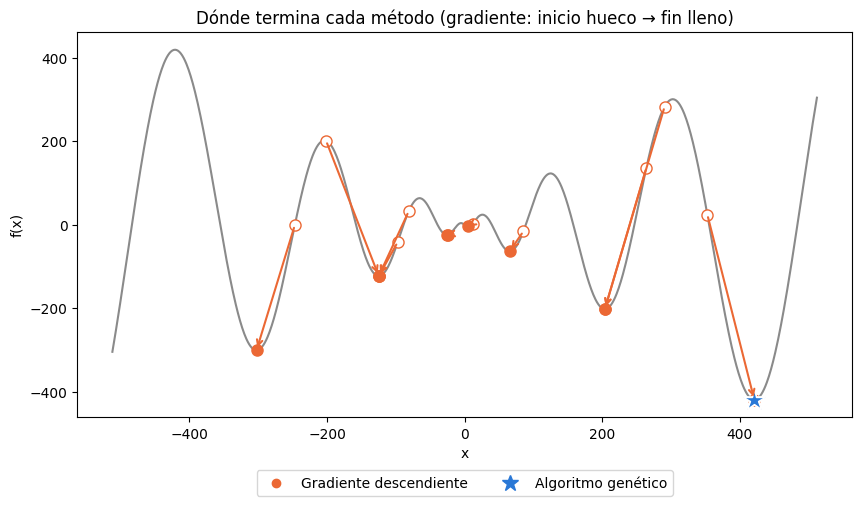

In [19]:
graficar_comparacion(f1, limites1, resultados_ag1, resultados_gd1)

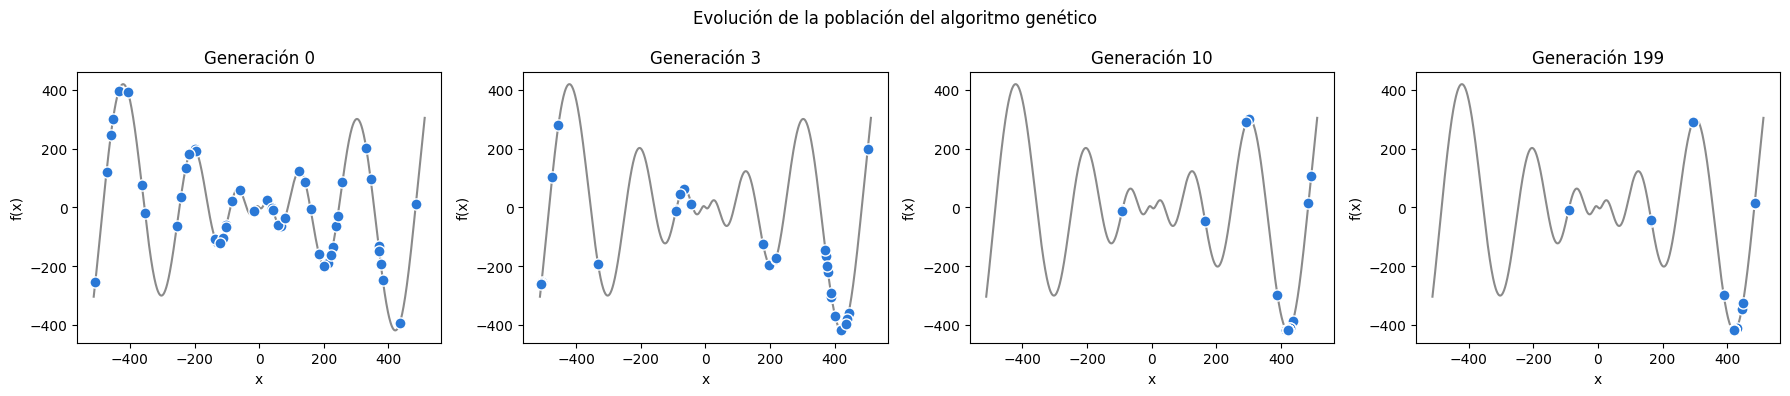

In [20]:
random.seed(0)
poblacion = poblacion_inicial(BITS)
punto, aptitud, poblaciones, mejores, aptitudes_mejores = algoritmo_genetico(poblacion, decodificar1, aptitud1)
graficar_evolucion(f1, limites1, poblaciones, generaciones=[0, 3, 10, 199])

**Inciso 2**: $f(x, y) = (x^2 + y^2)^{0.25} \left[\sin^2\left(50(x^2+y^2)^{0.1}\right) + 1\right], \quad -100 \leq x, y \leq 100$

In [21]:
def f2(punto):
    x = punto[0]
    y = punto[1]
    r2 = x**2 + y**2
    return r2**0.25 * (math.sin(50 * r2**0.1)**2 + 1)

limites2 = [(-100, 100), (-100, 100)]

def decodificar2(individuo):
    return decodificar_punto(individuo, limites2)

def aptitud2(individuo):
    return -f2(decodificar2(individuo))

resultados_ag2 = []
for semilla in range(corridas):
    random.seed(semilla)
    poblacion = poblacion_inicial(2 * BITS)     #20 bits para x y 20 para y
    punto, aptitud, poblaciones, mejores, aptitudes_mejores = algoritmo_genetico(poblacion, decodificar2, aptitud2)
    resultados_ag2.append((punto, -aptitud))     #f = -aptitud

random.seed(0)
resultados_gd2 = []
for i in range(corridas):
    inicio = [random.uniform(-100, 100), random.uniform(-100, 100)]
    resultados_gd2.append(gradiente_descendiente(f2, inicio, limites2, tasa=0.1))

comparar(resultados_ag2, resultados_gd2, f_optimo=0)

,mejor f,f promedio,llegó al mínimo global
Algoritmo genético,0.019960,0.019960,10/10
Gradiente descendiente,4.104469,7.893694,0/10


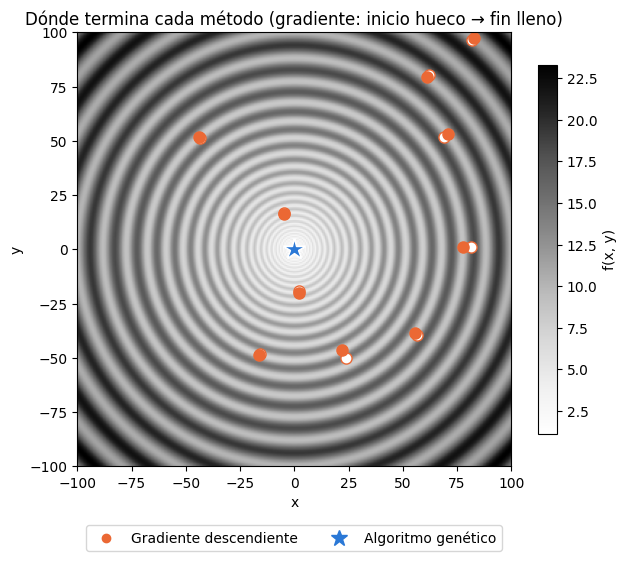

In [22]:
graficar_comparacion(f2, limites2, resultados_ag2, resultados_gd2)

En 3D se ve por qué el gradiente no llega al mínimo global: cada camino baja hasta el pozo más cercano y queda atrapado en uno de los anillos. El algoritmo genético llega al fondo, cerca de $(0, 0)$.

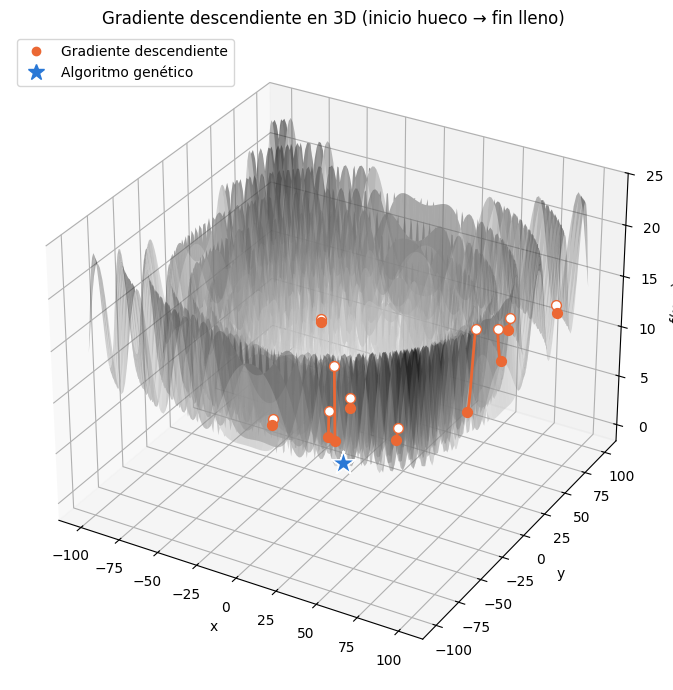

In [23]:
graficar_gradiente_3d(f2, limites2, resultados_ag2, resultados_gd2)

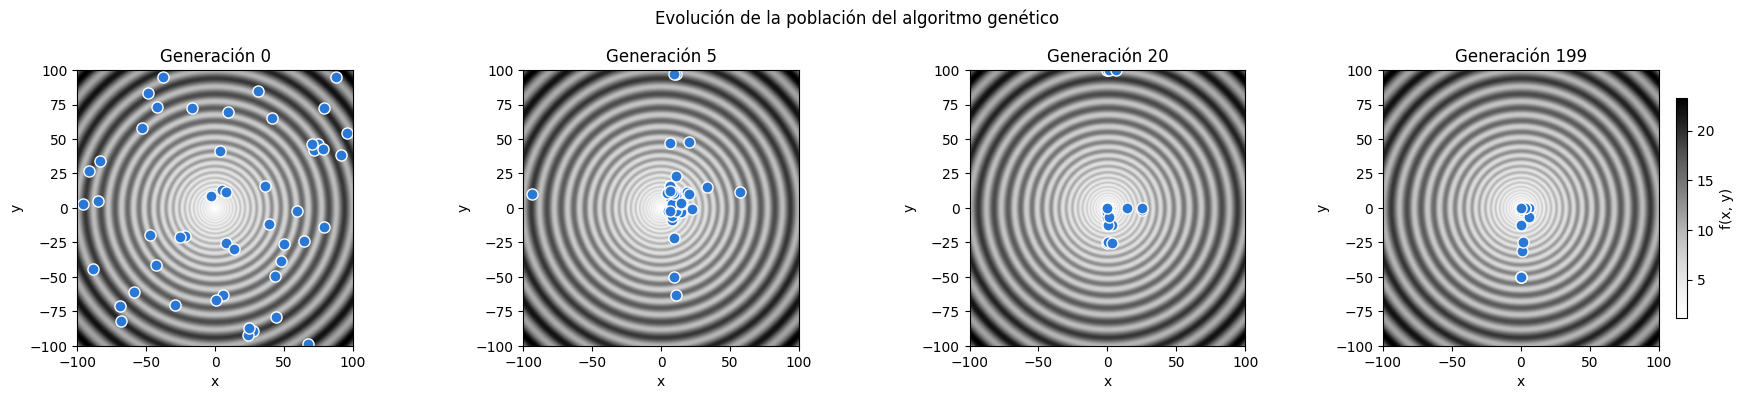

In [24]:
random.seed(0)
poblacion = poblacion_inicial(2 * BITS)
punto, aptitud, poblaciones, mejores, aptitudes_mejores = algoritmo_genetico(poblacion, decodificar2, aptitud2)
graficar_evolucion(f2, limites2, poblaciones, generaciones=[0, 5, 20, 199])

### Conclusiones

**Inciso 1: $f(x)$**

- El algoritmo genético llegó al mínimo global en las 10 corridas. Siempre terminó en $x \approx 420.97$, con $f \approx -418.98$.
- El gradiente llegó en 1 de 10 corridas: la única que arrancó dentro del valle del mínimo global ($x_0 = 352.7$). Las otras 9 terminaron en el mínimo local más cercano a su punto de partida ($x \approx -302.5,\ -124.8,\ -25.9,\ 5.2,\ 65.5,\ 203.8$). Por eso su $f$ promedio es $-158$, lejos de $-418.98$.

**Inciso 2: $f(x, y)$**

- El genético llegó en las 10 corridas, a un punto a $0.0001$ del origen, con $f = 0.02$. No llega a $f = 0$ porque con 20 bits por variable el valor 0 no existe: el más cercano es $\pm 0.0001$. Y cerca del origen $f$ sube muy rápido, así que a esa distancia ya vale $0.02$.
- El gradiente no llegó nunca. La función tiene anillos de mínimos locales alrededor del origen. Cada corrida baja al anillo más cercano y se queda ahí, casi en el mismo lugar donde arrancó: por ejemplo, de $x = 68.9$ a $x = 70.7$. El gráfico 3D lo muestra.

**Velocidad y costo**

| | Gradiente descendiente | Algoritmo genético |
|---|---|---|
| Llegó al mínimo global, inciso 1 | 1/10 | 10/10 |
| Llegó al mínimo global, inciso 2 | 0/10 | 10/10 |
| Iteraciones hasta terminar / llegar, inciso 1 | 18 a 50 | generación 1 a 33 (10 en promedio) |
| Iteraciones hasta terminar / llegar, inciso 2 | 4 a 69 | generación 18 a 66 (33 en promedio) |
| Evaluaciones de $f$ por iteración | 2 por variable | 50 (una por individuo) |

- El gradiente es más barato: en menos de 70 iteraciones deja de moverse, con pocas evaluaciones de $f$. Pero se detiene en un mínimo local.
- El genético necesita muchas más evaluaciones: unas 500 en el inciso 1 y unas 1650 en el inciso 2 hasta llegar al mínimo global.

**En resumen**

- El gradiente sólo mira la pendiente en el punto donde está. Por eso encuentra el mínimo más cercano al punto de partida. Sirve cuando la función tiene un solo mínimo o cuando se arranca cerca del global.
- El algoritmo genético evalúa muchos puntos a la vez, repartidos por todo el dominio, y la selección concentra la población en la mejor zona. Cuesta más evaluaciones, pero no depende del punto de partida. En funciones con muchos mínimos locales, como estas dos, es la mejor opción.

## Ejercicio 2

Diseñe e implemente un algoritmo genético que busque el mejor subconjunto de características para la clasificación de cáncer (leucemia linfocítica aguda y leucemia mielógena aguda) a partir de datos genómicos. Se proveen 38 muestras en el conjunto de entrenamiento y 34 en el conjunto de prueba (`leukemia_train.csv` y `leukemia_test.csv`, respectivamente). Cada muestra se compone de un total de 7129 características, que corresponden a valores de expresión génica.

### Idea

Es el esquema de *selección de características con algoritmos genéticos* (envolvente o *wrapper*): el AG propone subconjuntos de genes y un clasificador dice qué tan buenos son.

```mermaid
flowchart LR
    A["Individuo:<br/>máscara de bits<br/>1 = uso el gen<br/>0 = lo descarto"] --> B["Genes<br/>seleccionados"]
    B --> C["Clasificador:<br/>vecino más cercano<br/>(validación dejando<br/>uno afuera, solo en train)"]
    C --> D["Aptitud = UAR − β ·<br/>(genes usados /<br/>genes posibles)"]
    D --> E["Algoritmo genético<br/>(misma función<br/>del ejercicio 1)"]
    E --> A
```

**Decisiones:**

- **Test no se usa en la búsqueda.** La aptitud se mide en train (validación dejando uno afuera); test se usa una sola vez al final. Si no, el resultado queda inflado.
- **UAR** en vez de accuracy: las clases están desbalanceadas (27 ALL / 11 AML).
- **Vecino más cercano**: sin azar ni entrenamiento, el mismo individuo siempre tiene la misma aptitud.
- **Normalizar** cada gen con media y desvío de train: los rangos van de 21 a 12 500.
- **Penalizar la cantidad de genes** ($\beta$): a igual UAR, gana el subconjunto más chico.
- **Prefiltro**: el AG busca entre los 50 genes con mayor señal/ruido $\frac{|\mu_{ALL} - \mu_{AML}|}{\sigma_{ALL} + \sigma_{AML}}$ (Golub et al., 1999). Sobre los 7129 genes el AG sobreajustaba: UAR de test entre 0.48 y 0.79.

### Implementación

#### Leer los datos

Esta función lee un archivo. Cada fila es un paciente: los primeros valores son los genes y el último es la clase (0 = ALL, 1 = AML).

In [25]:
#los archivos NO tienen fila de encabezado: cada fila es un paciente, la última columna es la clase
def leer_csv(nombre):
    X = []
    y = []
    with open(nombre) as archivo:
        for fila in csv.reader(archivo):
            valores = []
            for v in fila[:-1]:
                valores.append(float(v))
            X.append(valores)
            y.append(int(float(fila[-1])))
    return X, y

X_train, y_train = leer_csv("leukemia_train.csv")
X_test, y_test = leer_csv("leukemia_test.csv")
n_genes = len(X_train[0])

print("train:", len(X_train), "pacientes,", y_train.count(0), "ALL y", y_train.count(1), "AML")
print("test: ", len(X_test), "pacientes,", y_test.count(0), "ALL y", y_test.count(1), "AML")
print("genes:", n_genes)

train: 38 pacientes, 27 ALL y 11 AML
test:  34 pacientes, 20 ALL y 14 AML
genes: 7129


#### Normalizar

Cada gen tiene una escala distinta. Esta celda calcula la media y el desvío de cada gen **sólo con train**. Después, en train y en test, a cada gen le resta la media y lo divide por el desvío. Así todos los genes pesan parecido en la distancia.

In [26]:
#normalizo cada gen con la media y el desvío de TRAIN (test no se mira)
medias = []
desvios = []
for j in range(n_genes):
    suma = 0
    for paciente in X_train:
        suma = suma + paciente[j]
    media = suma / len(X_train)

    suma_cuadrados = 0
    for paciente in X_train:
        suma_cuadrados = suma_cuadrados + (paciente[j] - media) ** 2
    desvio = math.sqrt(suma_cuadrados / len(X_train))

    medias.append(media)
    desvios.append(desvio)

def normalizar(X):
    X_normalizado = []
    for paciente in X:
        fila = []
        for j in range(n_genes):
            fila.append((paciente[j] - medias[j]) / desvios[j])
        X_normalizado.append(fila)
    return X_normalizado

X_train = normalizar(X_train)
X_test = normalizar(X_test)

#### Clasificador: vecino más cercano

`distancia` mide qué tan distintos son dos pacientes, mirando sólo los genes elegidos. `clasificar` busca el paciente de referencia más parecido y devuelve su clase.

In [27]:
#distancia (al cuadrado) entre dos pacientes, mirando solo los genes elegidos
def distancia(a, b, genes):
    suma = 0
    for g in genes:
        suma = suma + (a[g] - b[g]) ** 2
    return suma

#vecino más cercano: el paciente nuevo recibe la clase del paciente más parecido
def clasificar(paciente, X_ref, y_ref, genes):
    mas_cercano = 0
    for i in range(len(X_ref)):
        if distancia(paciente, X_ref[i], genes) < distancia(paciente, X_ref[mas_cercano], genes):
            mas_cercano = i
    return y_ref[mas_cercano]

#### UAR

Esta función calcula el porcentaje de aciertos de cada clase y los promedia. Las dos clases pesan lo mismo, aunque una tenga más pacientes.

In [28]:
#UAR: promedio del porcentaje de aciertos de cada clase
def uar(reales, predichas):
    suma_recalls = 0
    for clase in [0, 1]:
        total = 0
        aciertos = 0
        for i in range(len(reales)):
            if reales[i] == clase:
                total = total + 1
                if predichas[i] == clase:
                    aciertos = aciertos + 1
        suma_recalls = suma_recalls + aciertos / total
    return suma_recalls / 2

#### Validación dejando uno afuera

Esta función mide qué tan buenos son los genes usando sólo train. Saca un paciente, lo clasifica con los otros 37 y repite con cada paciente. El algoritmo genético usa esta medida.

In [29]:
#validación dejando uno afuera: cada paciente de train se clasifica con los otros 37
def uar_validacion(genes):
    predichas = []
    for i in range(len(X_train)):
        X_resto = X_train[:i] + X_train[i + 1:]
        y_resto = y_train[:i] + y_train[i + 1:]
        predichas.append(clasificar(X_train[i], X_resto, y_resto, genes))
    return uar(y_train, predichas)

#### Evaluación en test

Esta función clasifica cada paciente de test con los 38 de train. Se usa una sola vez, al final.

In [30]:
#evaluación final: cada paciente de test se clasifica con los 38 de train
def uar_test(genes):
    predichas = []
    for paciente in X_test:
        predichas.append(clasificar(paciente, X_train, y_train, genes))
    return uar(y_test, predichas)

#### Prefiltro por señal/ruido

Esta celda calcula, para cada gen, la relación señal/ruido $\frac{|\mu_{ALL} - \mu_{AML}|}{\sigma_{ALL} + \sigma_{AML}}$. Un gen con valor alto separa bien las dos clases. El algoritmo genético busca sólo entre los 50 genes con valor más alto.

In [31]:
#relación señal/ruido de cada gen (calculada solo con train)
def senal_ruido(j):
    valores_all = []
    valores_aml = []
    for i in range(len(X_train)):
        if y_train[i] == 0:
            valores_all.append(X_train[i][j])
        else:
            valores_aml.append(X_train[i][j])

    media_all = sum(valores_all) / len(valores_all)
    media_aml = sum(valores_aml) / len(valores_aml)

    desvio_all = 0
    for v in valores_all:
        desvio_all = desvio_all + (v - media_all) ** 2
    desvio_all = math.sqrt(desvio_all / len(valores_all))

    desvio_aml = 0
    for v in valores_aml:
        desvio_aml = desvio_aml + (v - media_aml) ** 2
    desvio_aml = math.sqrt(desvio_aml / len(valores_aml))

    return abs(media_all - media_aml) / (desvio_all + desvio_aml)

#ordeno los genes de mayor a menor señal/ruido y me quedo con los 50 primeros
pares = []
for j in range(n_genes):
    pares.append((senal_ruido(j), j))
pares.sort(reverse=True)

candidatos = []
for k in range(50):
    candidatos.append(pares[k][1])

print("10 mejores genes por señal/ruido:", candidatos[:10])

10 mejores genes por señal/ruido: [2019, 3319, 4846, 5771, 1744, 1833, 2287, 5038, 3846, 460]


### El problema del ejercicio 2

El individuo es una **máscara** de 50 bits, uno por gen candidato: 1 = uso el gen, 0 = no lo uso.

Esta función crea una máscara con pocos genes prendidos (10 en promedio). Con la mitad prendidos, el algoritmo arrancaría con demasiados genes.

In [32]:
#problema del ejercicio 2: el individuo es una mascara sobre los 50 genes candidatos
BETA = 0.2      #penalizacion por cantidad de genes

#arranco con pocos genes prendidos (10 en promedio), no con la mitad
def crear_mascara_chica(n_bits):
    individuo = []
    for i in range(n_bits):
        if random.random() < 10 / n_bits:
            individuo.append(1)
        else:
            individuo.append(0)
    return individuo

Esta función pasa la máscara a la lista de genes que usa.

In [33]:
#paso la mascara a la lista de genes que usa
def decodificar_genes(individuo):
    genes = []
    for i in range(len(individuo)):
        if individuo[i] == 1:
            genes.append(candidatos[i])
    return genes

Esta función calcula la aptitud: el UAR de validación menos una penalización por la cantidad de genes. A igual UAR, gana la máscara con menos genes.

$$\text{aptitud} = \text{UAR} - \beta \cdot \frac{\text{genes usados}}{50}$$

In [34]:
#aptitud = UAR de validacion - BETA * (proporcion de genes usados)
def aptitud_genes(individuo):
    genes = decodificar_genes(individuo)
    if len(genes) == 0:
        return 0
    return uar_validacion(genes) - BETA * len(genes) / len(individuo)

### Resultados

Corro el AG 5 veces (semillas distintas). Para cada corrida muestro los genes elegidos, el UAR de validación (lo que vio el AG) y el UAR de test (datos que el AG nunca vio).

In [35]:
corridas2 = 5
historias = []      #(mejores, aptitudes_mejores) de cada corrida, para graficar
filas = []
for semilla in range(corridas2):
    random.seed(semilla)

    #poblacion inicial: 30 mascaras con pocos genes
    poblacion = []
    for i in range(30):
        poblacion.append(crear_mascara_chica(len(candidatos)))

    genes, aptitud, poblaciones, mejores, aptitudes_mejores = algoritmo_genetico(
        poblacion, decodificar_genes, aptitud_genes, max_generaciones=60)
    historias.append((mejores, aptitudes_mejores))
    filas.append([semilla, genes, len(genes), uar_validacion(genes), uar_test(genes)])

tabla_corridas = pd.DataFrame(filas, columns=["semilla", "genes", "cantidad", "UAR validación", "UAR test"])
tabla_corridas

,semilla,genes,cantidad,UAR validación,UAR test
0,0,"[1744, 6470, 2120, 4051]",4,1.0,0.867857
1,1,"[4846, 2353]",2,1.0,0.939286
2,2,"[460, 6973, 4051]",3,1.0,0.757143
3,3,"[3319, 1248, 148]",3,1.0,0.785714
4,4,"[2758, 6538, 6375]",3,1.0,0.807143


In [36]:
#comparación con usar todos los genes y con quedarse directamente con los mejores del ranking
todos = list(range(n_genes))

suma_val = 0
suma_test = 0
suma_cantidad = 0
for fila in filas:
    suma_cantidad = suma_cantidad + fila[2]
    suma_val = suma_val + fila[3]
    suma_test = suma_test + fila[4]

pd.DataFrame([
    ["Todos los genes", n_genes, uar_validacion(todos), uar_test(todos)],
    ["3 mejores por señal/ruido (sin AG)", 3, uar_validacion(candidatos[:3]), uar_test(candidatos[:3])],
    ["10 mejores por señal/ruido (sin AG)", 10, uar_validacion(candidatos[:10]), uar_test(candidatos[:10])],
    ["50 candidatos por señal/ruido (sin AG)", 50, uar_validacion(candidatos), uar_test(candidatos)],
    ["Algoritmo genético (promedio de 5 corridas)", suma_cantidad / corridas2, suma_val / corridas2, suma_test / corridas2],
], columns=["método", "genes", "UAR validación", "UAR test"])

,método,genes,UAR validación,UAR test
0,Todos los genes,7129.0,0.799663,0.760714
1,3 mejores por señal/ruido (sin AG),3.0,0.936027,0.857143
2,10 mejores por señal/ruido (sin AG),10.0,1.000000,0.928571
3,50 candidatos por señal/ruido (sin AG),50.0,0.954545,0.964286
4,Algoritmo genético (promedio de 5 corridas),3.0,1.000000,0.831429


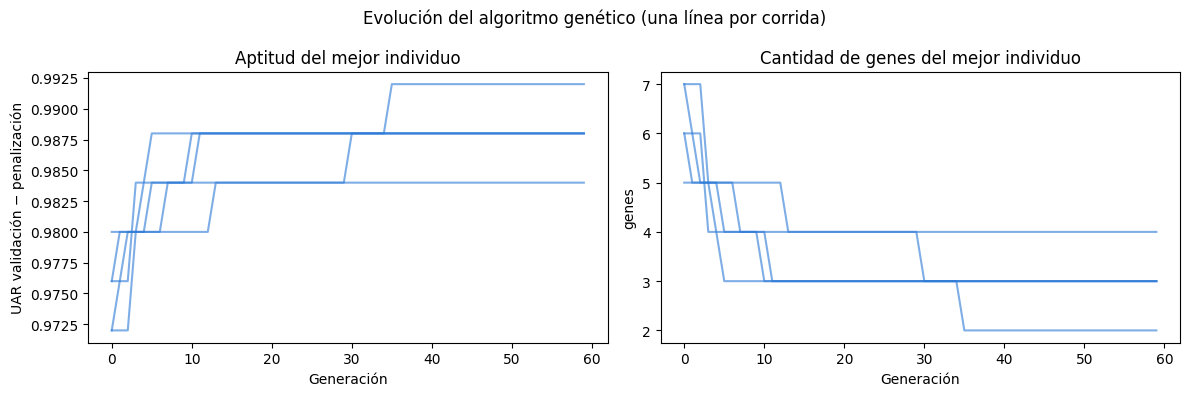

In [37]:
#como evoluciona el mejor individuo de cada corrida
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
for mejores, aptitudes_mejores in historias:
    cantidades = []
    for genes in mejores:
        cantidades.append(len(genes))
    ejes[0].plot(aptitudes_mejores, color=AZUL, alpha=0.6)
    ejes[1].plot(cantidades, color=AZUL, alpha=0.6)

ejes[0].set_title("Aptitud del mejor individuo")
ejes[0].set_xlabel("Generación")
ejes[0].set_ylabel("UAR validación − penalización")
ejes[1].set_title("Cantidad de genes del mejor individuo")
ejes[1].set_xlabel("Generación")
ejes[1].set_ylabel("genes")
fig.suptitle("Evolución del algoritmo genético (una línea por corrida)")
plt.tight_layout()
plt.show()

### Conclusiones

**Resultados**

- El algoritmo genético redujo los 7129 genes a 2–4 genes (3 en promedio). Con esos genes, el UAR de test promedio fue 0.83. Usando los 7129 genes fue 0.76.
- El resultado cambia mucho entre corridas. El UAR de test va de 0.76 a 0.94, y cada corrida elige genes distintos: sólo el gen 4051 aparece en dos corridas.

**Sobreajuste**

- El UAR de validación dio 1.0 en todas las corridas. El UAR de test fue más bajo en todas.
- Con 38 pacientes y 50 genes candidatos, muchas combinaciones chicas de genes separan perfecto a los pacientes de train por casualidad. Ya en la generación 0, el mejor individuo de cada corrida tenía UAR de validación 1.0, con 5 a 7 genes.
- Entonces la aptitud no distingue un subconjunto de genes bueno de uno que tuvo suerte con train. Lo único que el algoritmo puede mejorar es la penalización: en las generaciones siguientes sólo bajó la cantidad de genes, de 5–7 a 2–4.

**Comparación con el ranking señal/ruido (sin AG)**

- Con la misma cantidad de genes, el ranking simple es mejor: los 3 mejores genes por señal/ruido dan UAR de test 0.86, contra 0.83 del genético.
- Varios genes que eligió el genético están lejos en el ranking (puestos 28, 35, 39, 41, 47 y 48 de 50). El genético los eligió porque ayudan a separar train, no porque separen bien las dos clases en general.
- El mejor UAR de test (0.96) lo dan los 50 candidatos juntos, aunque su UAR de validación (0.96) es menor que el del genético (1.0). La validación en train no predice bien el resultado en test.

**En resumen**

- El algoritmo genético encuentra subconjuntos muy chicos (2–4 genes), pero no mejores que elegir los primeros del ranking señal/ruido.
- Con tan pocos pacientes, la validación dejando uno afuera llega a 1.0 muy fácil y deja de guiar la búsqueda. Para que el genético ayude haría falta una aptitud que no se sature tan rápido, o más pacientes.